# 타이타닉 생존자 예측

1. 데이터 확인
2. 결측치 처리
3. 인코딩
4. 모델학습/평가
5. 교차 검증
6. 하이퍼파라미터 튜닝
7. 튜닝된 하이퍼파라미터로 재학습

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

#한글 폰트 설정 (Mac은 AppleGothic)
plt.rcParams["font.family"] = "Malgun Gothic"

#마이너스 기호 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False

### 데이터 불러오기

In [4]:
titanic_df = pd.read_csv('data/titanic_train.csv')
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### 데이터 확인확인

In [5]:
titanic_df.info()   # 데이터 구조확인(Age, Cabin, Embarked  에 결측치 확인)

titanic_df.describe()   # 숫자형 컬럼 통계 확인

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
titanic_df.isna().sum()    # 컬럼별 결측치 갯수 확인

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

### 2. 결측치 처리

In [ ]:
# 'Age' 컬럼의 결측치를 평균치로 대체
titanic_df['Age'] = titanic_df['Age'].fillna(titanic_df['Age'].mean())

# 'Cabin' 컬럼의 결측치를 N 으로 대체
titanic_df['Cabin'] = titanic_df['Cabin'].fillna('N')

# 'Embarked' 컬럼의 결측치를 N 으로 대체
titanic_df['Embarked'] = titanic_df['Embarked'].fillna('N')


### 3. 범주형 데이터 확인
    - 문자 -> 숫자 인코딩 까지

In [10]:
titanic_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        891 non-null    str    
 11  Embarked     891 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [11]:
titanic_df['Cabin'].unique()    # Cabin 은 범주형이지만 정리가 필요해보임   

<StringArray>
[          'N',         'C85',        'C123',         'E46',          'G6',
        'C103',         'D56',          'A6', 'C23 C25 C27',         'B78',
 ...
        'B102',         'B69',         'E49',         'C47',         'D28',
         'E17',         'A24',         'C50',         'B42',        'C148']
Length: 148, dtype: str

In [12]:
titanic_df['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
N      2
Name: count, dtype: int64

In [13]:
titanic_df['Cabin'].value_counts()

Cabin
N              687
G6               4
C23 C25 C27      4
B96 B98          4
F33              3
              ... 
E17              1
A24              1
C50              1
B42              1
C148             1
Name: count, Length: 148, dtype: int64

In [14]:
titanic_df['Cabin'] = titanic_df['Cabin'].str[:1] # Cabin 문자열 첫 글자만 추출해서 저장
titanic_df['Cabin'].value_counts()

Cabin
N    687
C     59
B     47
D     33
E     32
A     15
F     13
G      4
T      1
Name: count, dtype: int64

### 4. 주요변수와 생존률 관계 시각화

In [15]:
# 성별이 생존률에 가장 큰 영향을 끼쳤다는 상식에 근거하여 확인
titanic_df.groupby(['Sex', 'Survived'])['Survived'].count()

Sex     Survived
female  0            81
        1           233
male    0           468
        1           109
Name: Survived, dtype: int64

<Axes: xlabel='Sex', ylabel='Survived'>

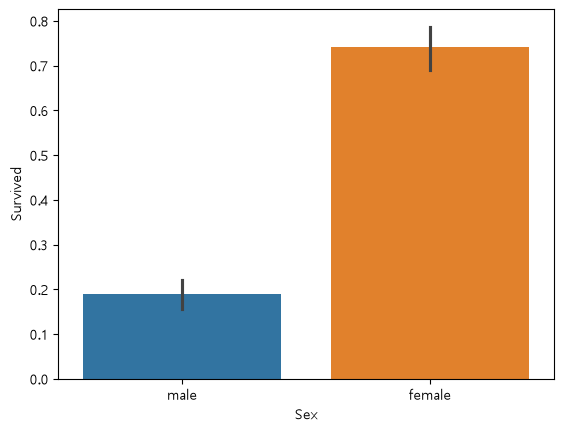

In [16]:
sns.barplot(x= 'Sex', y= 'Survived',hue='Sex', data= titanic_df)

<Axes: xlabel='Age_type', ylabel='Survived'>

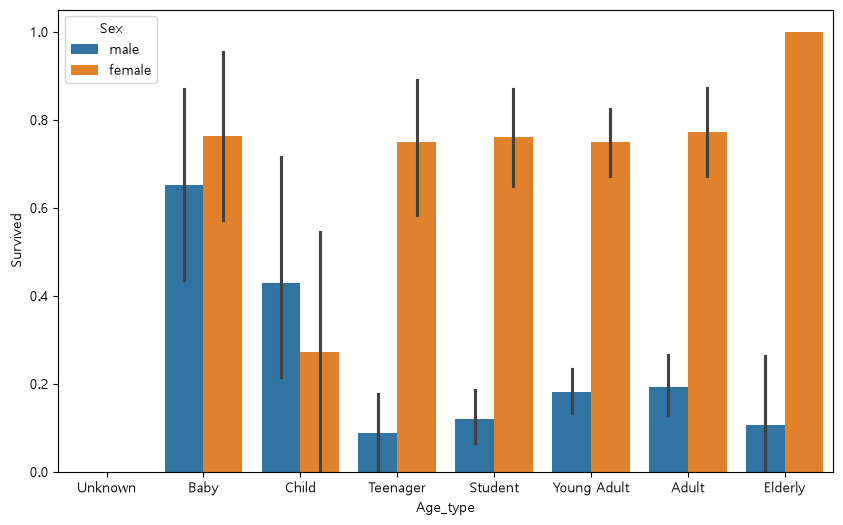

In [23]:
def get_category(age):
    age_type = ''
    if age <= -1 : age_type = 'Unknown'
    elif age <=5 : age_type = 'Baby'
    elif age <=12 : age_type = 'Child'
    elif age <=18 : age_type = 'Teenager'
    elif age <=25 : age_type = 'Student'
    elif age <=35 : age_type = 'Young Adult'
    elif age <=60 : age_type = 'Adult'
    else :age_type = 'Elderly'
    
    return age_type

plt.figure(figsize=(10, 6))
group_name = ['Unknown','Baby','Child','Teenager','Student','Young Adult','Adult','Elderly']

# Age 컬럼값을 각각 get_category 함수 적용해서 파생변수 생성
titanic_df["Age_type"] = titanic_df['Age'].apply(lambda x: get_category(x))
sns.barplot(x= 'Age_type', y= 'Survived',hue='Sex', data= titanic_df, order=group_name)

나이가 생존여부에 영향을 많이 끼치는걸로 보인다.  
어린 남성도 상대적으로 생존율이 높았다.

In [24]:
titanic_df.drop('Age_type', axis=1,inplace=True)

### 5. 범주형 데이터 인코딩

In [ ]:
from sklearn.preprocessing import LabelEncoder

def encode_features(dataDF):
    features = ['Cabin','Sex','Embarked']   # 인코딩할 컬럼 목록
    
    # LabelEncoder : 카테고리 값의 유형수에 따라 0 ~ (카테고리 유형수 -1 ) 까지의 숫자값으로 변환
    for feature in features:
        le = LabelEncoder()
        le = le.fit(dataDF[feature])    # 현재 컬럼의 종류 학습
        dataDF[feature] = le.transform(dataDF[feature])     # 학습한 기준으로 실제값을 숫자로 변환
        
    return dataDF

titanic_df = encode_features(titanic_df)
titanic_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.000000,1,0,A/5 21171,7.2500,7,3
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.000000,1,0,PC 17599,71.2833,2,0
2,3,1,3,"Heikkinen, Miss. Laina",0,26.000000,0,0,STON/O2. 3101282,7.9250,7,3
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.000000,1,0,113803,53.1000,2,3
4,5,0,3,"Allen, Mr. William Henry",1,35.000000,0,0,373450,8.0500,7,3
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",1,27.000000,0,0,211536,13.0000,7,3
887,888,1,1,"Graham, Miss. Margaret Edith",0,19.000000,0,0,112053,30.0000,1,3
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",0,29.699118,1,2,W./C. 6607,23.4500,7,3
889,890,1,1,"Behr, Mr. Karl Howell",1,26.000000,0,0,111369,30.0000,2,0


### 6. 전처리 함수화

In [29]:
# 결측치 처리 함수
def fillna(df):
    
    df = df.copy()  # 원본 Dataframe 은 직접 수정하지 않고 복사본 만들어서 반환
    
    df['Age'] = df['Age'].fillna(df['Age'].mean())
    df['Cabin'] = df['Cabin'].fillna('N')
    df['Embarked'] = df['Embarked'].fillna('N')

    return df

# 불필요한 컬럼 제거 함수
def drop_features(df):
    
    df = df.copy()
    
    df = df.drop(['PassengerId','Name', 'Ticket'], axis= 1)
    return df


# 레이블 인코딩 함수
def format_features(df):
    
    df = df.copy()
    
    df['Cabin'] = df['Cabin'].str[:1]
    
    features = ['Cabin','Sex','Embarked']   # 인코딩할 컬럼 목록
    
    # LabelEncoder : 카테고리 값의 유형수에 따라 0 ~ (카테고리 유형수 -1 ) 까지의 숫자값으로 변환
    for feature in features:
        le = LabelEncoder()
        le = le.fit(df[feature])    # 현재 컬럼의 종류 학습
        df[feature] = le.transform(df[feature])     # 학습한 기준으로 실제값을 숫자로 변환
        
    return df


# EDA 처리 및 통합전처리 함수
def transform_features(df):
    df = fillna(df)
    df = drop_features(df)
    df = format_features(df)
    
    return df

### 7. 피처 데이터와 레이블 데이터 분리

In [32]:
titanic_df = pd.read_csv('data/titanic_train.csv')

y_titanic_df = titanic_df['Survived']   # Survived 열만 남기기
x_titanic_df = titanic_df.drop('Survived', axis=1)  # Survived 열빼고 남기기


# 결측치 처리, 불필요한 컬럼 제거, 범주형 데이터 인코딩 수행
x_titanic_df = transform_features(x_titanic_df)

x_titanic_df

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,3,1,22.000000,1,0,7.2500,7,3
1,1,0,38.000000,1,0,71.2833,2,0
2,3,0,26.000000,0,0,7.9250,7,3
3,1,0,35.000000,1,0,53.1000,2,3
4,3,1,35.000000,0,0,8.0500,7,3
...,...,...,...,...,...,...,...,...
886,2,1,27.000000,0,0,13.0000,7,3
887,1,0,19.000000,0,0,30.0000,1,3
888,3,0,29.699118,1,2,23.4500,7,3
889,1,1,26.000000,0,0,30.0000,2,0


기본적인 전치리는 완료되었으나, 성능 향상적인 측면에서 데이터 스케일링 작업을 추가할 수도 있다.  
DecisionTree, RandomForest 계열은 데이터 스케일링 영향이 적다.  
만약 Logistic 계열을 사용한다면 해주는게 대부분 더 좋다.

### 8. 학습데이터와 테스트 데이터 분리

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test  = train_test_split(
    x_titanic_df,
    y_titanic_df,
    test_size= 0.2,
    random_state= 11
)


# 학습데이터와 테스트 데이터가 8:2로 잘나뉘었는지 확인
print(len(X_train),len(X_test),len(y_train),len(y_test))

712 179 712 179


### 9. 기본 모델 학습 및 평가

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

dt_clf = DecisionTreeClassifier(random_state=11)
rf_clf = RandomForestClassifier(random_state=11)
lr_clf = LogisticRegression(solver= 'liblinear')    # 최적화 계산 알고리즘으로 liblinear(이진분류용) 사용


# DecisionTreeClassifier 학습 / 예측 / 평가
dt_clf.fit(X_train, y_train)
dt_pred = dt_clf.predict(X_test)
print(f"DecisionTreeClassifier의 정확도 : {accuracy_score(dt_pred, y_test):.4f}")

# RandomForestClassifier의 학습 / 예측 / 평가
rf_clf.fit(X_train, y_train)
rf_pred = rf_clf.predict(X_test)
print(f"RandomForestClassifier의 정확도 : {accuracy_score(rf_pred, y_test):.4f}")

# LogisticRegression의 학습 / 예측 / 평가
lr_clf.fit(X_train, y_train)
lr_pred = lr_clf.predict(X_test)
print(f"LogisticRegression의 정확도 : {accuracy_score(lr_pred, y_test):.4f}")

DecisionTreeClassifier의 정확도 : 0.7877
RandomForestClassifier의 정확도 : 0.8547
LogisticRegression의 정확도 : 0.8659


### 10. k-Fold 교차검증
위의 코드는 한번의 train_test 분리만 해서 성능 비교해봤기 때문에 데이터 분할 방식에 따라 결과가 흔들릴 수 있다.  
그래서 데이터를 여러번 나눠서 평균 성능을 확인해 보는 k-Fold를 사용한다.

In [ ]:
from sklearn.model_selection import KFold

# K-Fold 교차검증 실행 함수
def exec_kfold(clf, folds= 5):
    kfold = KFold(n_splits= folds)
    scores = []
    
    # X_titanic_df 데이터에서 교차 검증별로 train_index, test_index 생성
    for iter_count, (train_index, test_index) in enumerate(kfold.split(x_titanic_df)):
        
        # train_index, test_index 인덱스를 활용하여 kfold 분리 데이터 지정
        X_train, X_test = x_titanic_df.values[train_index], x_titanic_df.values[test_index]
        y_train, y_test = y_titanic_df.values[train_index], y_titanic_df.values[test_index]
        
        # Classifier 학습, 예측, 정확도 계산
        clf.fit(X_train,y_train)
        predictions = clf.predict(X_test)
        accuracy = accuracy_score(predictions, y_test)
        scores.append(accuracy)
        
        print(f"교차 검증 {iter_count + 1} 정확도 : {accuracy:.4f}")

    mean_scores = np.mean(scores)
    print(f"평균 정확도 : {mean_scores:.4f}")
    
# 결정트리 
exec_kfold(dt_clf,folds= 5)

교차 검증 1 정확도 : 0.7542
교차 검증 2 정확도 : 0.7809
교차 검증 3 정확도 : 0.7865
교차 검증 4 정확도 : 0.7697
교차 검증 5 정확도 : 0.8202
평균 정확도 : 0.7823


In [ ]:
# 랜덤포레스트
exec_kfold(rf_clf,folds= 5)

교차 검증 1 정확도 : 0.7933
교차 검증 2 정확도 : 0.8090
교차 검증 3 정확도 : 0.8371
교차 검증 4 정확도 : 0.7753
교차 검증 5 정확도 : 0.8596
평균 정확도 : 0.8148


In [ ]:
# 로지스틱
exec_kfold(lr_clf,folds= 5)

교차 검증 1 정확도 : 0.7933
교차 검증 2 정확도 : 0.7921
교차 검증 3 정확도 : 0.7753
교차 검증 4 정확도 : 0.7472
교차 검증 5 정확도 : 0.8427
평균 정확도 : 0.7901


In [49]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(dt_clf, x_titanic_df, y_titanic_df, cv=5)  # cv = k개
for iter_count, accuracy in enumerate(scores):
    print(f"교차 검증 {iter_count + 1} 정확도 : {accuracy:.4f}")
    
print(f'평균 정확도 : {np.mean(scores):.4f}')

교차 검증 1 정확도 : 0.7430
교차 검증 2 정확도 : 0.7753
교차 검증 3 정확도 : 0.7921
교차 검증 4 정확도 : 0.7865
교차 검증 5 정확도 : 0.8427
평균 정확도 : 0.7879


### 11. 하이퍼파라미터 최적화 도구 GridSearchCV
- 미리 정해둔 파라미터 조합을 모두 시도해 가장 좋은 조합을 찾아낸다.
- 탐색 범위가 적을때에는 사용하기 용이하지만, 조합이 많아지면 많아질수록 실행 시간이 급격하게 늘어날 수 있다.

In [ ]:
from sklearn.model_selection import GridSearchCV

parameters = {
    'max_depth' : [2, 3, 5, 10],        # 4배 탐색
    'min_samples_split' : [2, 3, 5],    # 4배 탐색
    'min_samples_leaf' : [1, 5, 8]      # 3배 탐색
}

grid_dclf = GridSearchCV(dt_clf, param_grid=parameters, scoring='accuracy', cv= 5)
grid_dclf.fit(X_train, y_train)

print(f"GridSearchCV의 최적의 하이퍼파라미터 :{grid_dclf.best_params_}")
print(f"GridSearchCV의 최적의 정확도 :{grid_dclf.best_score_}")
best_dclf = grid_dclf.best_estimator_

GridSearchCV의 최적의 하이퍼파라미터 :{'max_depth': 3, 'min_samples_leaf': 5, 'min_samples_split': 2}
GridSearchCV의 최적의 정확도 :0.7991825076332119


In [56]:
dpredctions = best_dclf.predict(X_test)
accuracy = accuracy_score(dpredctions, y_test)

print(f"테스트 데이터셋에서의 정확도 :{accuracy:.4f}")

테스트 데이터셋에서의 정확도 :0.8715


### 12. Optuna 하이퍼파라미터 튜닝
- 모든 조합을 단순하게 반복하지 않고, 이전 trail 결과를 참고해 더 좋은 조합을 찾아낸다.
- Optuna 에서 나온 교차검증 점수는 학습데이터로 나온것이므로, 차후 테스트 데이터로 검증을 다시 해야한다. 

In [66]:
import optuna
from optuna.samplers import TPESampler  # 이전의 실험 결과를 보고, 성능이 좋을 것같은 조합을 탐색하는 기법
from sklearn.model_selection import StratifiedKFold, cross_val_score 
from sklearn.tree import DecisionTreeClassifier

# Optuna 로그가 너무많이 출력되지 않도록 경고 메세지만 출력
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    #Optuna 가 한번에 trial 에서 사용할 하이퍼파라미터를 제안
    params = {
        'max_depth' : trial.suggest_int('max_depth',2,10),
        'min_samples_split' : trial.suggest_int('min_samples_split',2, 10),
        'min_samples_leaf' : trial.suggest_int('min_samples_leaf',1, 10),
        'criterion' :  trial.suggest_categorical('criterion', ['gini','entropy']),  # 노드 분리 기준(지니 불순도, 엔트로피)
        'random_state' : 11
    }

    model = DecisionTreeClassifier(**params)
    
    # 생존/ 사망 비율 fold 마다 비슷하게 유지되도록 StratifiedKFold 사용
    cv = StratifiedKFold(n_splits= 5, shuffle= True, random_state=11)
    
    # 5-fold 교차검증 정확도 계산
    scores = cross_val_score(model, X_train, y_train, cv= cv, scoring='accuracy')
    
    # 교차검증 정확도의 평균이 최대화 되는 방향으로 학습
    return scores.mean()

sampler = TPESampler(seed=11)
study = optuna.create_study(direction='maximize', sampler=sampler)

study.optimize(objective, n_trials= 200) # n_trials 가 증가되면 시간은 증가되지만, 더 많이 시도해서 탐색

print(f"Optuna의  최적의 하이퍼파라미터 :{study.best_params}")
print(f"Optuna의 최적의 정확도 :{study.best_value:.4f}")

Optuna의  최적의 하이퍼파라미터 :{'max_depth': 8, 'min_samples_split': 6, 'min_samples_leaf': 1, 'criterion': 'entropy'}
Optuna의 최적의 정확도 :0.8061


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

best_params = study.best_params.copy()

# optuna로 찾은 최적의 하이퍼 파라미터 적용한 의사결정나무 분류모델
final_optuna_model = DecisionTreeClassifier(**best_params, random_state=11)

final_optuna_model.fit(X_train, y_train)    # 학습

final_pred = final_optuna_model.predict(X_test) # 예측

final_accuracy = accuracy_score(y_test, final_pred) # 정확도

print(f"최적의 하이퍼파라미터 :{best_params}")
print(f"최적의 정확도 :{study.best_value:.4f}")
print(f"최적의 정확도 :{final_accuracy:.4f}")



최적의 하이퍼파라미터 :{'max_depth': 8, 'min_samples_split': 6, 'min_samples_leaf': 1, 'criterion': 'entropy'}
최적의 정확도 :0.8061
최적의 정확도 :0.8324


In [ ]:
cm = confusion_matrix(y_test, final_pred)   # 혼동행렬

# 행 : 실제값 , 열: 예측값
cm_df = pd.DataFrame(
    cm,
    index = ['Actual 0','Actual 1'],
    columns= ['Predicted 0','Predicted 1']
)

cm_df

,Predicted 0,Predicted 1
Actual 0,113,5
Actual 1,25,36


In [ ]:
# accuracy, precision, recall, f1-score 한번에 출력하는 보고서
print(classification_report(y_test, final_pred, target_names=['사망(0)','생존(1)']))


              precision    recall  f1-score   support

       사망(0)       0.82      0.96      0.88       118
       생존(1)       0.88      0.59      0.71        61

    accuracy                           0.83       179
   macro avg       0.85      0.77      0.79       179
weighted avg       0.84      0.83      0.82       179



In [74]:
comparison_df = pd.DataFrame({
    'Model' : [
        'DecisionTree 기본 모델',
        'RandomForest 기본 모델',
        'LogisticRegression 기본 모델',
        'GridSearchCV DecisionTree',
        'Optuna DecisionTree'
    ],
    "Test Accuracy" :[
        accuracy_score(y_test, dt_pred),   
        accuracy_score(y_test, rf_pred),   
        accuracy_score(y_test, lr_pred),   
        accuracy_score(y_test, dpredctions), 
        final_accuracy  
    ]
})

comparison_df.sort_values('Test Accuracy', ascending=False)

,Model,Test Accuracy
3,GridSearchCV DecisionTree,0.871508
2,LogisticRegression 기본 모델,0.865922
1,RandomForest 기본 모델,0.854749
4,Optuna DecisionTree,0.832402
0,DecisionTree 기본 모델,0.787709


### 고도화 
1. DecisionTree 모델밖에 사용하지 않았으니, RandomForest / LogistucRegression / Boosting (선택) 계열 다른 모델을 사용해서 하이퍼파라미터 최적화해서 성능을 극대화 시켜본다.

2. 여러가지 방식으로 성능 개선
- LabelEncoding -> 원핫인코딩
- 스케일러 적용

3. 학습 데이터셋은 학습에만 사용하고, 테스트 데이터셋을 추가로 다운받아 테스트용으로만 사용

### RandomForest 

In [81]:
import optuna
from optuna.samplers import TPESampler  # 이전의 실험 결과를 보고, 성능이 좋을 것같은 조합을 탐색하는 기법
from sklearn.model_selection import StratifiedKFold, cross_val_score 
from sklearn.ensemble import RandomForestClassifier

# Optuna 로그가 너무많이 출력되지 않도록 경고 메세지만 출력
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    #Optuna 가 한번에 trial 에서 사용할 하이퍼파라미터를 제안
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth' : trial.suggest_int('max_depth',2,10),
        'min_samples_split' : trial.suggest_int('min_samples_split',2, 10),
        'min_samples_leaf' : trial.suggest_int('min_samples_leaf',1, 10),
        'criterion' :  trial.suggest_categorical('criterion', ['gini','entropy']),  # 노드 분리 기준(지니 불순도, 엔트로피)
        'random_state' : 11,
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'n_jobs': -1
    }

    model = RandomForestClassifier(**params)
    
    # 생존/ 사망 비율 fold 마다 비슷하게 유지되도록 StratifiedKFold 사용
    cv = StratifiedKFold(n_splits= 5, shuffle= True, random_state=11)
    
    # 5-fold 교차검증 정확도 계산
    scores = cross_val_score(model, X_train, y_train, cv= cv, scoring='accuracy')
    
    # 교차검증 정확도의 평균이 최대화 되는 방향으로 학습
    return scores.mean()

sampler = TPESampler(seed=11)
study = optuna.create_study(direction='maximize', sampler=sampler)

study.optimize(objective, n_trials= 50) # n_trials 가 증가되면 시간은 증가되지만, 더 많이 시도해서 탐색

print(f"Optuna의  최적의 하이퍼파라미터 :{study.best_params}")
print(f"Optuna의 최적의 정확도 :{study.best_value:.4f}")

Optuna의  최적의 하이퍼파라미터 :{'n_estimators': 405, 'max_depth': 8, 'min_samples_split': 10, 'min_samples_leaf': 10, 'criterion': 'entropy', 'max_features': 'sqrt'}
Optuna의 최적의 정확도 :0.8104


In [83]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

best_params = study.best_params.copy()

# optuna로 찾은 최적의 하이퍼 파라미터 적용한 의사결정나무 분류모델
final_optuna_model = RandomForestClassifier(**best_params, random_state=11)

final_optuna_model.fit(X_train, y_train)    # 학습

final_pred = final_optuna_model.predict(X_test) # 예측

final_accuracy = accuracy_score(y_test, final_pred) # 정확도

print(f"최적의 하이퍼파라미터 :{best_params}")
print(f"최적의 예측 :{study.best_value:.4f}")
print(f"최적의 정확도 :{final_accuracy:.4f}")



최적의 하이퍼파라미터 :{'n_estimators': 405, 'max_depth': 8, 'min_samples_split': 10, 'min_samples_leaf': 10, 'criterion': 'entropy', 'max_features': 'sqrt'}
최적의 예측 :0.8104
최적의 정확도 :0.8771


### LogisticRegression

In [85]:
import optuna
from optuna.samplers import TPESampler  # 이전의 실험 결과를 보고, 성능이 좋을 것같은 조합을 탐색하는 기법
from sklearn.model_selection import StratifiedKFold, cross_val_score 
from sklearn.linear_model import LogisticRegression

# Optuna 로그가 너무많이 출력되지 않도록 경고 메세지만 출력
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    #Optuna 가 한번에 trial 에서 사용할 하이퍼파라미터를 제안
    params = {
    "C": trial.suggest_float("C", 1e-3, 100, log=True),
    "solver": trial.suggest_categorical("solver", ["liblinear", "lbfgs"]),
    "max_iter": 1000,
    "random_state": 11
}

    model = LogisticRegression(**params)
    
    # 생존/ 사망 비율 fold 마다 비슷하게 유지되도록 StratifiedKFold 사용
    cv = StratifiedKFold(n_splits= 5, shuffle= True, random_state=11)
    
    # 5-fold 교차검증 정확도 계산
    scores = cross_val_score(model, X_train, y_train, cv= cv, scoring='accuracy')
    
    # 교차검증 정확도의 평균이 최대화 되는 방향으로 학습
    return scores.mean()

sampler = TPESampler(seed=11)
study = optuna.create_study(direction='maximize', sampler=sampler)

study.optimize(objective, n_trials= 50) # n_trials 가 증가되면 시간은 증가되지만, 더 많이 시도해서 탐색

print(f"Optuna의  최적의 하이퍼파라미터 :{study.best_params}")
print(f"Optuna의 최적의 정확도 :{study.best_value:.4f}")

Optuna의  최적의 하이퍼파라미터 :{'C': 0.9847681692571688, 'solver': 'liblinear'}
Optuna의 최적의 정확도 :0.7823


In [86]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

best_params = study.best_params.copy()

# optuna로 찾은 최적의 하이퍼 파라미터 적용한 의사결정나무 분류모델
final_optuna_model = LogisticRegression(**best_params, random_state=11)

final_optuna_model.fit(X_train, y_train)    # 학습

final_pred = final_optuna_model.predict(X_test) # 예측

final_accuracy = accuracy_score(y_test, final_pred) # 정확도

print(f"최적의 하이퍼파라미터 :{best_params}")
print(f"최적의 예측 :{study.best_value:.4f}")
print(f"최적의 정확도 :{final_accuracy:.4f}")



최적의 하이퍼파라미터 :{'C': 0.9847681692571688, 'solver': 'liblinear'}
최적의 예측 :0.7823
최적의 정확도 :0.8659
